In [1]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import pandas as pd

data = []
df1 = pd.read_csv('data/tsne_sample/hotel.tsv', sep="\t")
df1["topic"] = df1["topic"].replace({"food & drinks": "food"})

df2 = pd.read_csv('data/tsne_sample/restaurant.tsv', sep="\t")

df = pd.concat([df1, df2], ignore_index=True)


df_filt = df[
    df["topic"].isin(["rooms", "service", "location", 'food']) &
    df["sentiment"].isin(["positive", "negative"])
]

samples = (
    df_filt
    .groupby(["topic", "sentiment"], group_keys=False)
    .apply(lambda x: x.sample(n=30, random_state=42))
)

for sentence, topic, sentiment in zip(samples["text"], samples['topic'], samples['sentiment']):
    if topic not in ["rooms", "location", "service", 'food']: continue
    if topic == "service": topic = "STAFF"
    if topic == "rooms": topic = "room"
    data.append({"sentence": sentence, "topic": topic.upper(), "sentiment": "pos" if sentiment == "positive" else "neg"})

/tmp/ipykernel_4326/3850600653.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=30, random_state=42))


In [3]:
samples.groupby(["topic", "sentiment"]).size().unstack(fill_value=0)


sentiment,negative,positive
topic,,
food,30,30
location,30,30
rooms,30,30
service,30,30


In [5]:
sentences = [d["sentence"] for d in data]
topics = [d["topic"] for d in data]
sentiments = [d["sentiment"] for d in data]

In [8]:
topic_shapes = {
    "ROOM": "o",                  # Circle
    "LOCATION": "X",                # Diamond
    "STAFF": "s",
    "FOOD": "d"
}


sentiment_colors = {
    "neg": "#E69F00",
    "pos": "#0072B2",
}

In [9]:
# -------------------------


sentences = [d["sentence"].lower() for d in data]
topics = [d["topic"] for d in data]
sentiments = [d["sentiment"] for d in data]

# -------------------------
# Models
# -------------------------
models = {
    "all-mpnet-base-v2": SentenceTransformer("all-mpnet-base-v2", device="cpu"),
    "StanceSBERT": SentenceTransformer("vahidthegreat/StanceAware-SBERT", device="cpu"),
    "TourCSE": SentenceTransformer("data/sbert/export/hotel/all-mpnet-base-v2_lora_guided_sg_250", device="cpu")
}

# -------------------------
# Embeddings + UMAP
# -------------------------
from sklearn.preprocessing import MinMaxScaler
import umap

embeddings_dict = {}
umap_dict = {}

for name, model in models.items():
    # Encode sentences
    emb = model.encode(sentences, show_progress_bar=True)
    embeddings_dict[name] = emb


No sentence-transformers model found with name vahidthegreat/StanceAware-SBERT. Creating a new one with mean pooling.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [ ]:
for name, model in models.items():
    
    emb = embeddings_dict[name]
    # Apply UMAP
    #umap_model = umap.UMAP(n_neighbors=15, min_dist=0, metric="cosine", random_state=42)
    #umap_model = PCA(n_components=2)
    umap_model = TSNE(n_components=2, random_state=42)
    emb_2d = umap_model.fit_transform(emb)

    # Normalize to [0, 1] per dimension
    scaler = MinMaxScaler()
    emb_2d_norm = scaler.fit_transform(emb_2d)

    umap_dict[name] = emb_2d_norm

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.cluster import KMeans

# Create combined topic+sentiment labels
combined_labels = [f"{t}_{s}" for t, s in zip(topics, sentiments)]

unique_labels = {lbl: i for i, lbl in enumerate(sorted(set(combined_labels)))}
numeric_labels = np.array([unique_labels[l] for l in combined_labels])

n_clusters = len(unique_labels)

results = []

for model_name, emb in umap_dict.items():
    print(f"Computing metrics for: {model_name}")
    
    # clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(emb)

    sil = silhouette_score(emb, numeric_labels)
    cal = calinski_harabasz_score(emb, numeric_labels)
    db = davies_bouldin_score(emb, numeric_labels)

    results.append({
        "model": model_name,
        "silhouette": sil,
        "calinski_harabasz": cal,
        "davies_bouldin": db,
    })

df_metrics = pd.DataFrame(results)
df_metrics

Computing metrics for: all-mpnet-base-v2
Computing metrics for: StanceSBERT
Computing metrics for: TourCSE


,model,silhouette,calinski_harabasz,davies_bouldin
0,all-mpnet-base-v2,0.158545,127.581205,2.802718
1,StanceSBERT,-0.087510,36.293356,6.033808
2,TourCSE,0.305481,217.011141,1.210804


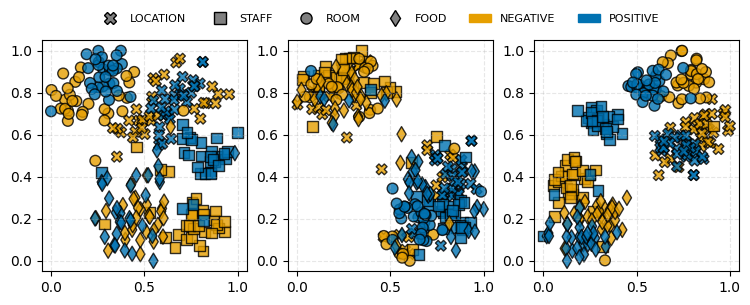

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load custom font

# Prepare figure: one row, one column per model
n_models = len(umap_dict)
fig, axes = plt.subplots(1, n_models, figsize=(3 * n_models, 3), constrained_layout=False)
import matplotlib.patches as mpatches

if n_models == 1:
    axes = [axes]  # Make iterable if only one model

for ax, (model_name, emb_2d) in zip(axes, umap_dict.items()):
    
    # Scatter plot per topic
    for topic in set(topics):
        idx = [i for i, t in enumerate(topics) if t == topic]
        x = emb_2d[idx, 0]
        y = emb_2d[idx, 1]
        c = [sentiment_colors[sentiments[i]] for i in idx]
        ax.scatter(
            x, y, c=c, marker=topic_shapes.get(topic, "o"),
            label=topic, edgecolor="k", s=60, alpha=0.8
        )
    
   
    
    ax.grid(True, linestyle="--", alpha=0.3)

# Topic legend handles
topic_handles = [plt.Line2D([0], [0], marker=topic_shapes.get(topic, "o"), color='w',
                             markerfacecolor='gray', markeredgecolor='k', markersize=8, label=topic)
                 for topic in set(topics)]

# Sentiment legend handles
sentiment_handles = [mpatches.Patch(color=color, label="POSITIVE" if label=="pos" else "NEGATIVE") 
                     for label, color in sentiment_colors.items()]

# Combine handles
all_handles = topic_handles + sentiment_handles

# Figure-level legend
fig.legend(handles=all_handles, loc='upper center', ncol=len(all_handles), fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.0))
#fig.savefig("data/article/umap_topics.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
sentiment_colors = {
    "negative": "#E69F00",           # Orange
    "positive": "#0072B2",           # Blue
    "indirect_positive": "#D3D3D3",  # Sky blue
    "indirect_negative": "#E69F00",  # Red-orange,
    "ambiguous": "#D3D3D3"
}

# Assign shapes to sentiment types for plotting
sentiment_shapes = {
    "positive": "o",          # Circle
    "negative": "s",          # Square
    "indirect_positive": "P", # Triangle up
    "indirect_negative": "X", # Triangle down,
    "ambiguous": "D"
}



In [16]:
positives = []
negatives = []
import json
with open("data/sentiments.json", "r") as f:
    data = json.load(f)
for v in data:
    if v[1] == "pos": positives.append(v[0])
    if v[1] == "neg": negatives.append(v[0])

positives = positives[:100]
negatives = negatives[:100]

In [17]:
import random

In [18]:
entities = ["room"]

r = "{entity} is {}"
r_ind = "{entity} is not {}"
r_amb = "{entity} is {a} but also {b}"

hotel_reviews_2 = []

for entity in entities:
    # Positives
    for p in positives:
        hotel_reviews_2.append({
            "entity": entity,
            "review": r.format(p, entity=entity),
            "sentiment": "positive"
        })

    for p in positives[:50]:
        hotel_reviews_2.append({
            "entity": entity,
            "review": r_ind.format(p, entity=entity),
            "sentiment": "indirect_negative"
        })

    # Negatives
    for n in negatives:
        hotel_reviews_2.append({
            "entity": entity,
            "review": r.format(n, entity=entity),
            "sentiment": "negative"
        })

    for n in negatives[:50]:
        hotel_reviews_2.append({
            "entity": entity,
            "review": r_ind.format(n, entity=entity),
            "sentiment": "indirect_positive"
        })

    # Ambiguous
    for p, n in zip(positives[:25], negatives[:25]):
        kp = random.choice(positives[:10])
        kn = random.choice(negatives[:10])

        hotel_reviews_2.append({
            "entity": entity,
            "review": r_amb.format(a=kp, b=kn, entity=entity),
            "sentiment": "ambiguous"
        })

        hotel_reviews_2.append({
            "entity": entity,
            "review": r_amb.format(a=n, b=kp, entity=entity),
            "sentiment": "ambiguous"
        })


In [19]:
sentences = [d["review"] for d in hotel_reviews_2]
sentiments = [d["sentiment"] for d in hotel_reviews_2]
entities_list = [d["entity"] for d in hotel_reviews_2]

In [20]:
# -------------------------
# Models
# -------------------------
models = {
    "all-mpnet-base-v2": SentenceTransformer("all-mpnet-base-v2", device="cpu"),
    "StanceSBERT": SentenceTransformer("vahidthegreat/StanceAware-SBERT", device="cpu"),
    "TourCSE": SentenceTransformer("data/sbert/export/hotel/all-mpnet-base-v2_lora_guided_sg_250", device="cpu")
}

# -------------------------
# Embeddings + UMAP
# -------------------------
from sklearn.preprocessing import MinMaxScaler
import umap

embeddings_dict = {}
umap_dict = {}

for name, model in models.items():
    # Encode sentences
    emb = model.encode(sentences, show_progress_bar=True)
    embeddings_dict[name] = emb

No sentence-transformers model found with name vahidthegreat/StanceAware-SBERT. Creating a new one with mean pooling.


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
for name, model in models.items():  
  # Apply UMAP
    emb =     embeddings_dict[name]
    #umap_model = umap.UMAP(n_neighbors=5, min_dist=0, metric="cosine", random_state=42)
    #umap_model = PCA(n_components=2)
    umap_model = TSNE(n_components=2, random_state=42)
    emb_2d = umap_model.fit_transform(emb)

    # Normalize to [0, 1] per dimension
    scaler = MinMaxScaler()
    emb_2d_norm = scaler.fit_transform(emb_2d)

    umap_dict[name] = emb_2d_norm

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.cluster import KMeans

# --------------------------------------------------
# 1. Sentiment merging
# --------------------------------------------------

merge_labels = {
    "positive": ["positive"],
    "negative": ["negative", "indirect_negative"],
    "ambiguous": ["ambiguous", "indirect_positive"],
}

def map_sentiment(s):
    for merged_label, original_labels in merge_labels.items():
        if s in original_labels:
            return merged_label
    return None  # unknown → discard

# Original sentiments: list[str]
merged_sentiments = np.array([map_sentiment(s) for s in sentiments])

# --------------------------------------------------
# 2. Remove ambiguous items (build a mask)
# --------------------------------------------------

mask = merged_sentiments != "ambiguous"

print(f"Removed {(~mask).sum()} ambiguous items out of {len(mask)}")

filtered_sentiments = merged_sentiments[mask]

# --------------------------------------------------
# 3. Encode labels (positive / negative)
# --------------------------------------------------

unique_labels = {lbl: i for i, lbl in enumerate(sorted(set(filtered_sentiments)))}
numeric_labels = np.array([unique_labels[l] for l in filtered_sentiments])

# Sanity check
assert len(numeric_labels) == mask.sum()

# --------------------------------------------------
# 4. Compute clustering metrics
# --------------------------------------------------

results = []

for model_name, emb in umap_dict.items():
    print(f"Computing metrics for: {model_name}")

    # IMPORTANT: filter embeddings with the same mask
    emb_filtered = emb[mask]

    # Extra safety check
    assert emb_filtered.shape[0] == len(numeric_labels)

    sil = silhouette_score(emb_filtered, numeric_labels)
    cal = calinski_harabasz_score(emb_filtered, numeric_labels)
    db = davies_bouldin_score(emb_filtered, numeric_labels)

    results.append({
        "model": model_name,
        "silhouette": sil,
        "calinski_harabasz": cal,
        "davies_bouldin": db,
    })

# --------------------------------------------------
# 5. Results table
# --------------------------------------------------

df_metrics = pd.DataFrame(results)
df_metrics


Removed 100 ambiguous items out of 324
Computing metrics for: all-mpnet-base-v2
Computing metrics for: StanceSBERT
Computing metrics for: TourCSE


,model,silhouette,calinski_harabasz,davies_bouldin
0,all-mpnet-base-v2,0.075715,6.113455,5.576695
1,StanceSBERT,0.577561,407.805075,0.623414
2,TourCSE,0.456424,201.156058,0.844679


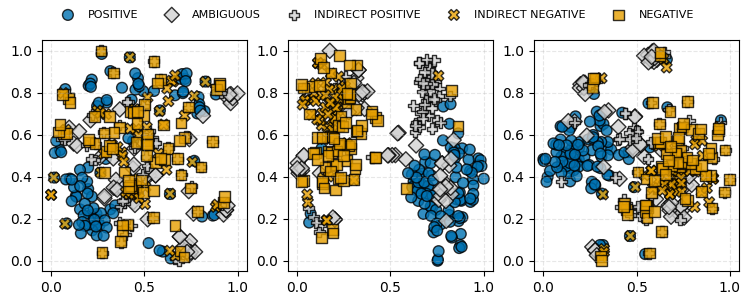

In [23]:
# Prepare figure: one row, one column per model
n_models = len(umap_dict)
fig, axes = plt.subplots(1, n_models, figsize=(3 * n_models, 3), constrained_layout=False)

if n_models == 1:
    axes = [axes]  # Make iterable if only one model

for ax, (model_name, emb_2d) in zip(axes, umap_dict.items()):
    
    for s in set(sentiments):
        # Indices of sentences for this sentiment
        idx = [i for i, t in enumerate(sentiments) if t == s]
        x = emb_2d[idx, 0]
        y = emb_2d[idx, 1]
        c = [sentiment_colors[sentiments[i]] for i in idx]
        
        
        ax.scatter(
            x, y,
            c=c,
            marker=sentiment_shapes.get(s, "o"),
            label=s,
            edgecolor="k",
            linewidths=1,
            s=60,
            alpha=0.8
        )
    

    ax.grid(True, linestyle="--", alpha=0.3)

# Legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, [l.upper().replace("_", " ") for l in labels], loc="upper center", ncol=len(set(sentiments)), fontsize=8, frameon=False)

fig.savefig("data/article/umap_sentiment.png", dpi=300, bbox_inches="tight")

# Then display
plt.show()